## Clustering

In [ ]:
# Importación de librerías para cambio de directorio y lectura
import pandas as pd
df= pd.read_csv('CC_GENERAL.csv')

#### Exploración de datos y Feature Engineering

In [2]:
df.sample(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3496,C13594,5998.431562,0.909091,0.00,0.0,0.00,7120.317519,0.000000,0.000000,0.0,0.083333,2,0,8500.0,1629.632001,1613.203482,0.0,12
8484,C18714,0.000000,0.000000,120.82,0.0,120.82,0.000000,0.500000,0.000000,0.5,0.000000,0,6,1000.0,275.029692,NaN,0.0,12
3888,C13998,3543.905366,1.000000,1362.92,0.0,1362.92,0.000000,1.000000,0.000000,1.0,0.000000,0,15,7500.0,1026.706561,1039.058094,0.0,12
8041,C18258,2935.397877,1.000000,0.00,0.0,0.00,343.694226,0.000000,0.000000,0.0,0.333333,10,0,3000.0,949.675235,2723.330171,0.0,12
4408,C14531,1381.274840,1.000000,71.80,71.8,0.00,0.000000,0.083333,0.083333,0.0,0.000000,0,1,3500.0,304.742004,415.236204,0.0,12


In [3]:
df.shape

(8950, 18)

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [2]:
# Conteo de ceros
df[df== 0].count()

CUST_ID                                0
BALANCE                               80
BALANCE_FREQUENCY                     80
PURCHASES                           2044
ONEOFF_PURCHASES                    4302
INSTALLMENTS_PURCHASES              3916
CASH_ADVANCE                        4628
PURCHASES_FREQUENCY                 2043
ONEOFF_PURCHASES_FREQUENCY          4302
PURCHASES_INSTALLMENTS_FREQUENCY    3915
CASH_ADVANCE_FREQUENCY              4628
CASH_ADVANCE_TRX                    4628
PURCHASES_TRX                       2044
CREDIT_LIMIT                           0
PAYMENTS                             240
MINIMUM_PAYMENTS                       0
PRC_FULL_PAYMENT                    5903
TENURE                                 0
dtype: int64

In [4]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [10]:
# Total de valores nulos
print(df.isnull().sum().sum())

314


In [14]:
# Detalle de valores nulos
print(df.isnull().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [3]:
# Buscar registros repetidos por ID
df['CUST_ID'].duplicated().sum()

np.int64(0)

<Axes: >

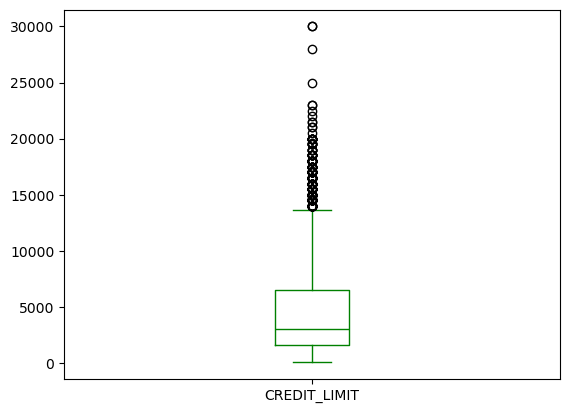

In [52]:
# Box plots de las variables con nulos para visualizar sesgos
df['CREDIT_LIMIT'].plot.box(color= 'green')

<Axes: >

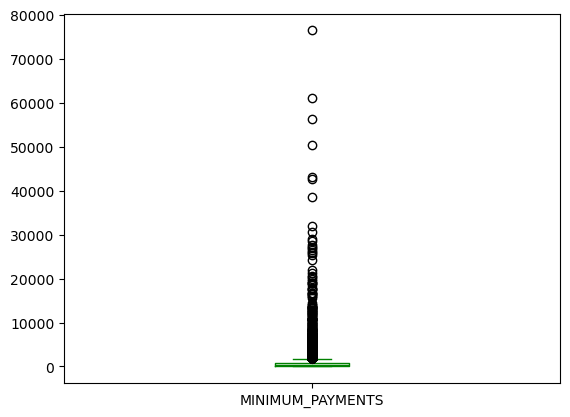

In [53]:
df['MINIMUM_PAYMENTS'].plot.box(color= 'green')

In [2]:
# Se importan las librerías para realizar la visualización de histogramas y matriz de correlación
import matplotlib.pyplot as plt
import seaborn as sns

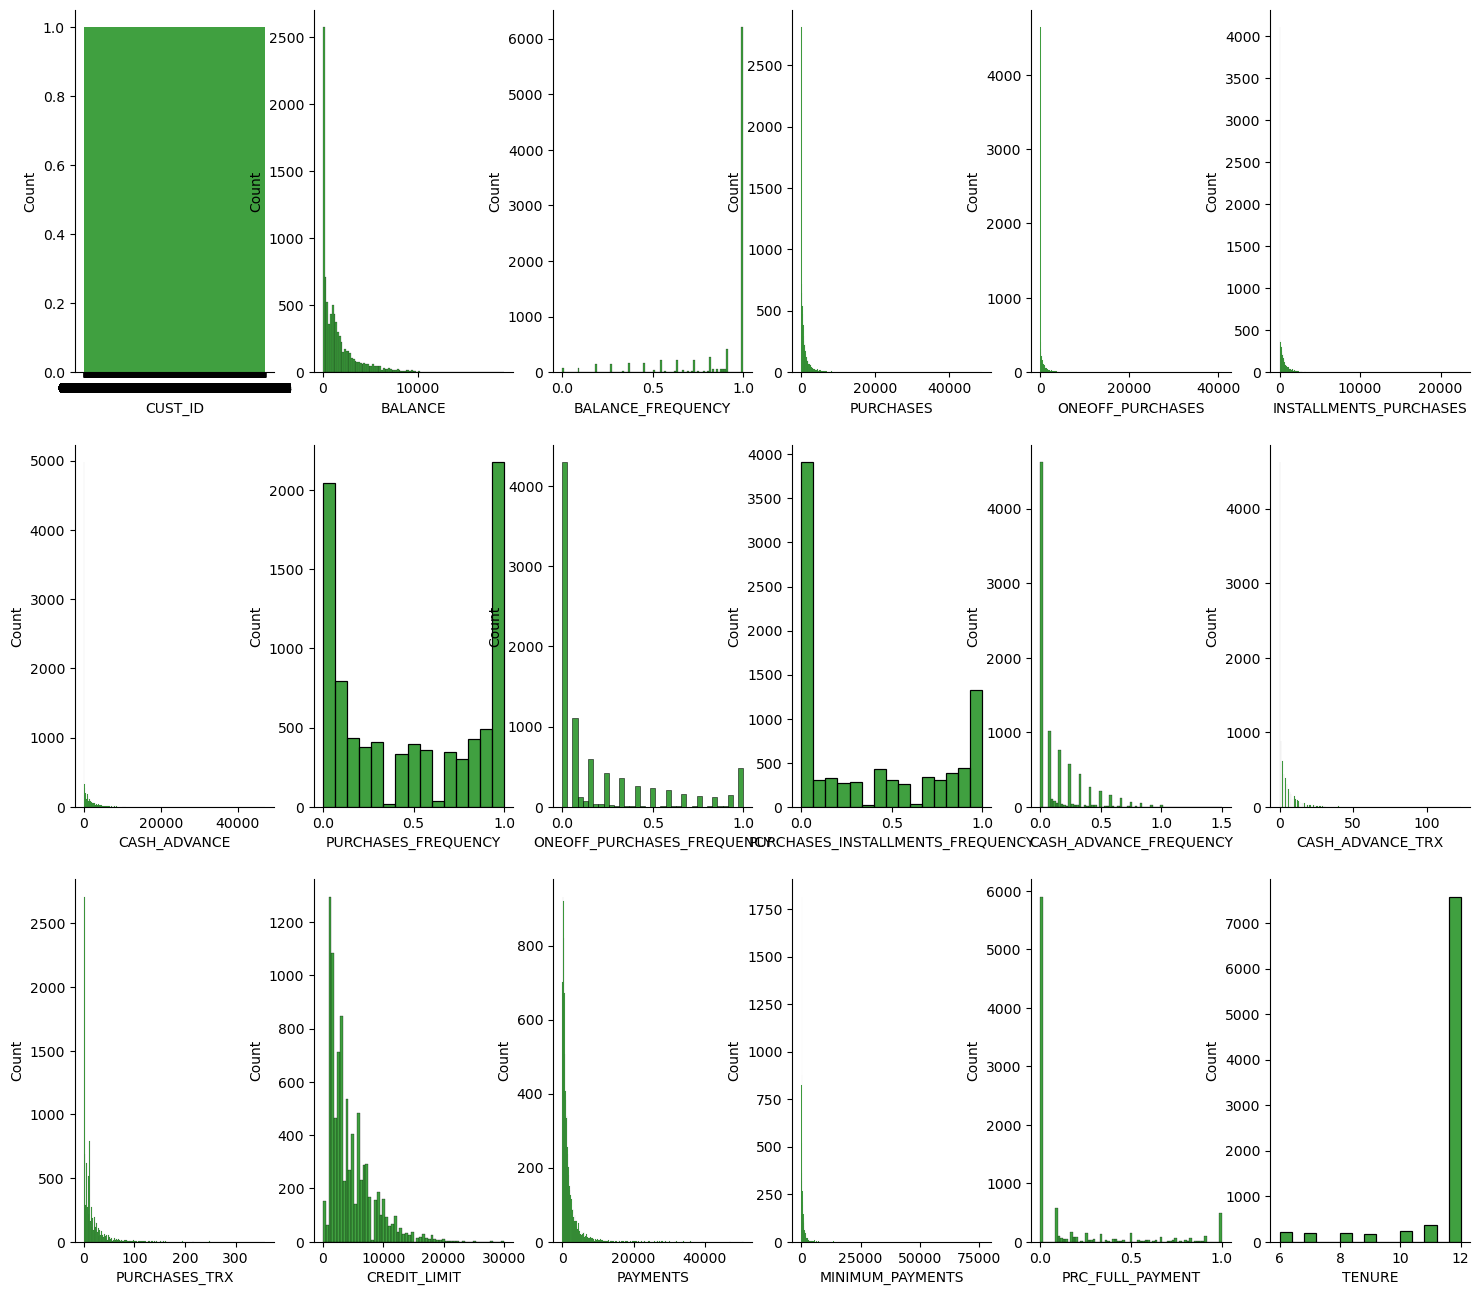

In [49]:
# Histogramas de dataset
fig, axes= plt.subplots(3, 6, figsize= (18, 16))
for i, column in enumerate(df):
    sns.histplot(df[column], ax= axes[i//6, i%6], kde= False, color= 'green')
    sns.despine()

In [3]:
# Copias del dataframe original para realizar cambios
df2= df.copy()

In [4]:
# Se elimina el ID del cliente
df2.drop('CUST_ID', axis= 1, inplace= True)

In [5]:
# Sesgos en el dataset
df2.skew().sort_values(ascending= False)


MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

In [6]:
# Imputación de datos en la variable Credit Limit
df2['CREDIT_LIMIT']= df2['CREDIT_LIMIT'].fillna(df2['CREDIT_LIMIT'].median())

In [7]:
# Imputación de datos en la variable Pagos mínimos
df2['MINIMUM_PAYMENTS']= df2['MINIMUM_PAYMENTS'].fillna(df2['MINIMUM_PAYMENTS'].median()) 

In [23]:
# Comprobamos las actualizaciones en nulos
print(df2.isnull().sum().sum())

0


In [ ]:
df_corr= df2.corr(method= 'pearson')
df_corr

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531296,0.322802,0.397920,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095931,0.065008,0.131181,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356977,0.603264,0.095789,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319735,0.567292,0.050256,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256515,0.384084,0.134019,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303997,0.453238,0.140747,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119833,0.103464,0.006154,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295059,0.243537,-0.027311,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060794,0.085551,0.032055,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132608,0.183192,0.100616,-0.249773,-0.133372


In [8]:
# Se importa numpy para personalizar la matriz triangular
import numpy as np

Text(0.5, 1.0, 'Heatmap de datos de tarjetas de crédito')

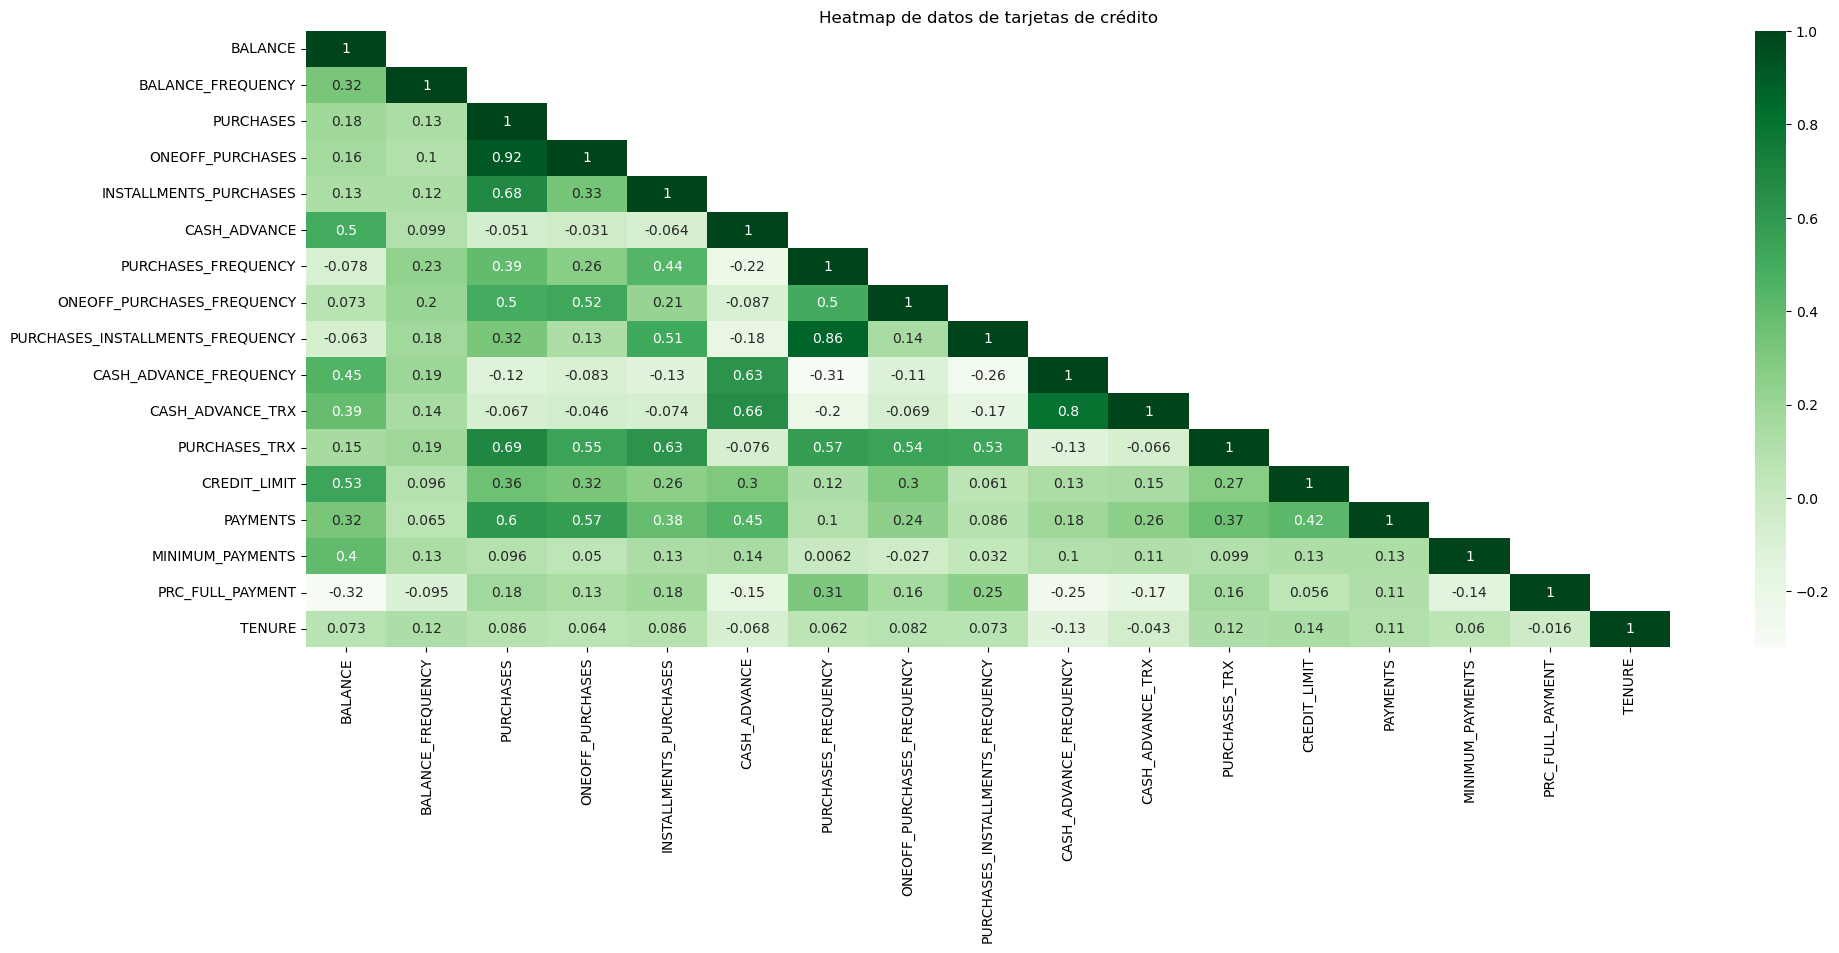

In [ ]:
# Generación de matriz de correlación
plt.figure(figsize= (22, 8))
heat= df_corr.where(np.tril(np.ones(df_corr.shape).astype(bool)))  # Creación de la máscara de booleanos y matriz triangular
sns.heatmap(heat, cmap= 'Greens', annot= True)
plt.title('Heatmap de datos de tarjetas de crédito')
plt.show()

In [61]:
# Comportamiento de ambas variables
df2[['ONEOFF_PURCHASES', 'PURCHASES']].sample(10)

,ONEOFF_PURCHASES,PURCHASES
4920,365.51,534.26
4562,1076.01,1076.01
3872,363.71,363.71
542,0.00,55.50
7614,1361.65,1361.65
90,1147.83,5100.07
7344,0.00,0.00
589,1456.94,1841.62
216,103.10,878.52
3050,170.00,170.00


In [9]:
# Se elimina la variable ONEOFF_PURCHASES
df2.drop('ONEOFF_PURCHASES', axis= 1, inplace= True)

<b>Observaciones:</b>
- Se realizó la imputación de datos por medio de la mediana en las variables 'Límite de crédito' y 'Pagos mínimos' ya que en ambas existían sesgos.<br><br>
- Se eliminó el ID del cliente y la variable 'Compras de una sola vez' por multicolinealidad.<br><br>
- Al tratarse de un dataset numérico, no se realiza agrupación ni balanceo de variables.

#### Estandarización de variables

In [ ]:
# Copia del df con los cambios guardados hasta ahora
df3= df2.copy()

In [11]:
# Estandarización Zscore
from scipy.stats import zscore
df2= df2.apply(zscore)

In [ ]:
# Longitud del df actualizado
df2.columns.__len__()

16

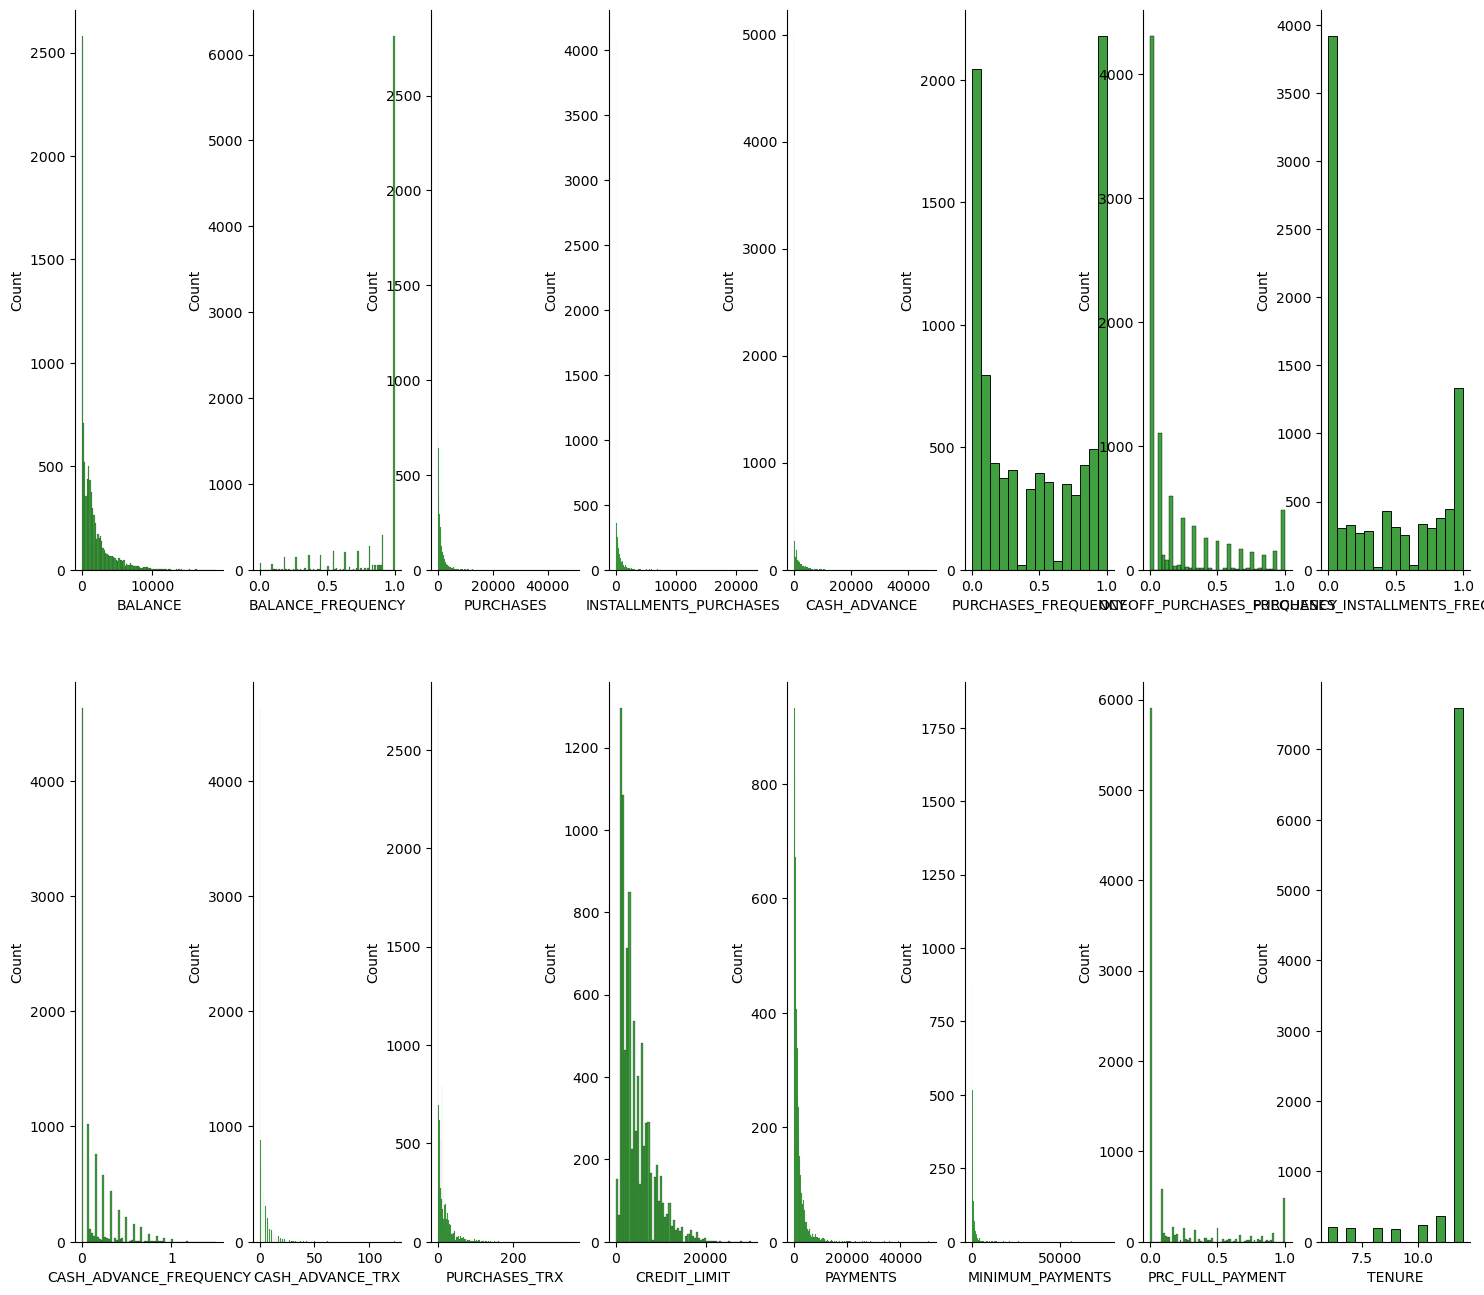

In [17]:
# Actualización de histogramas
fig, axes= plt.subplots(2, 8, figsize= (18, 16))
for i, column in enumerate(df2):
    sns.histplot(df[column], ax= axes[i//8, i%8], kde= False, color= 'green')
    sns.despine()

In [12]:
df2.skew()

BALANCE                              2.393386
BALANCE_FREQUENCY                   -2.023266
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
CASH_ADVANCE                         5.166609
PURCHASES_FREQUENCY                  0.060164
ONEOFF_PURCHASES_FREQUENCY           1.535613
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
CASH_ADVANCE_FREQUENCY               1.828686
CASH_ADVANCE_TRX                     5.721298
PURCHASES_TRX                        4.630655
CREDIT_LIMIT                         1.522636
PAYMENTS                             5.907620
MINIMUM_PAYMENTS                    13.852446
PRC_FULL_PAYMENT                     1.942820
TENURE                              -2.943017
dtype: float64

In [14]:
# Se modificará la segunda copia del dataframe. Sesgos:
df3.skew().sort_values()

TENURE                              -2.943017
BALANCE_FREQUENCY                   -2.023266
PURCHASES_FREQUENCY                  0.060164
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
CREDIT_LIMIT                         1.522636
ONEOFF_PURCHASES_FREQUENCY           1.535613
CASH_ADVANCE_FREQUENCY               1.828686
PRC_FULL_PAYMENT                     1.942820
BALANCE                              2.393386
PURCHASES_TRX                        4.630655
CASH_ADVANCE                         5.166609
CASH_ADVANCE_TRX                     5.721298
PAYMENTS                             5.907620
INSTALLMENTS_PURCHASES               7.299120
PURCHASES                            8.144269
MINIMUM_PAYMENTS                    13.852446
dtype: float64

In [ ]:
# Lista con las columnas sesgadas
cols= list(set(df3.columns) - {'PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY'})
cols

['PURCHASES',
 'MINIMUM_PAYMENTS',
 'BALANCE',
 'CASH_ADVANCE_TRX',
 'PRC_FULL_PAYMENT',
 'CASH_ADVANCE_FREQUENCY',
 'BALANCE_FREQUENCY',
 'TENURE',
 'ONEOFF_PURCHASES_FREQUENCY',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'PURCHASES_TRX',
 'CASH_ADVANCE',
 'INSTALLMENTS_PURCHASES']

In [ ]:
# Transformación Yeo-Johnson de variables con sesgo alto en la segunda copia del df original
from sklearn.preprocessing import PowerTransformer
pt= PowerTransformer(method= 'yeo-johnson')
df3[cols]= pt.fit_transform(df3[cols])

In [ ]:
# Estandarización de variables
df3= df3.apply(zscore)

In [ ]:
# Actualización de sesgos
df3.skew()

BALANCE                            -0.119428
BALANCE_FREQUENCY                  -1.118938
PURCHASES                          -0.178677
INSTALLMENTS_PURCHASES             -0.014843
CASH_ADVANCE                        0.188413
PURCHASES_FREQUENCY                 0.060164
ONEOFF_PURCHASES_FREQUENCY          0.541358
PURCHASES_INSTALLMENTS_FREQUENCY    0.509201
CASH_ADVANCE_FREQUENCY              0.506434
CASH_ADVANCE_TRX                    0.392581
PURCHASES_TRX                       0.006058
CREDIT_LIMIT                       -0.009651
PAYMENTS                            0.124631
MINIMUM_PAYMENTS                   -0.029965
PRC_FULL_PAYMENT                    0.963939
TENURE                             -1.971472
dtype: float64

<b>Observaciones:</b>
- Se realizan dos versiones de dataframes: en la primer copia se aplica la estandarización Zscore.<br><br>
- En la segunda copia se transforman las variables segadas con el método Yeo-Johnson (para sesgo negativo y registros con 0) y se aplica la estandarización Zscore.

#### Modelo de clustering K-Means: Gráfico de codo

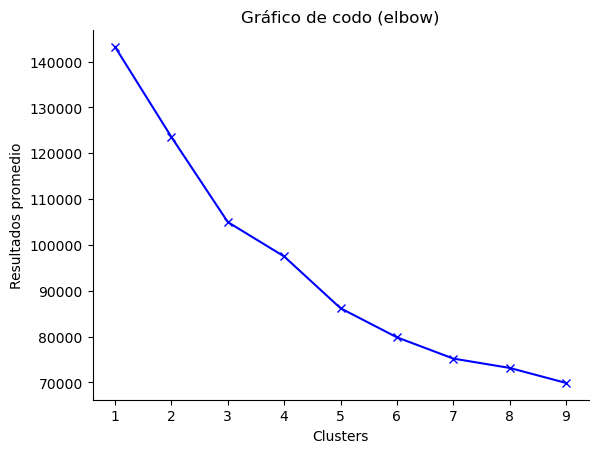

In [23]:
# Creación de gráfico de codo para distinguir el número óptimo de clusters (modelo estandarizado con Zscore)
from sklearn.cluster import KMeans
clusters= range(1, 10)
distortions= []
for k in clusters:
    model= KMeans(n_clusters= k, random_state= 42)
    model.fit(df2)
    distortions.append(model.inertia_)      # Inertia es la suma de distancias cuadradas de cada punto a su centroide
plt.plot(clusters, distortions, 'bx-')
plt.xlabel('Clusters')
plt.ylabel('Resultados promedio')
plt.title('Gráfico de codo (elbow)')
sns.despine()

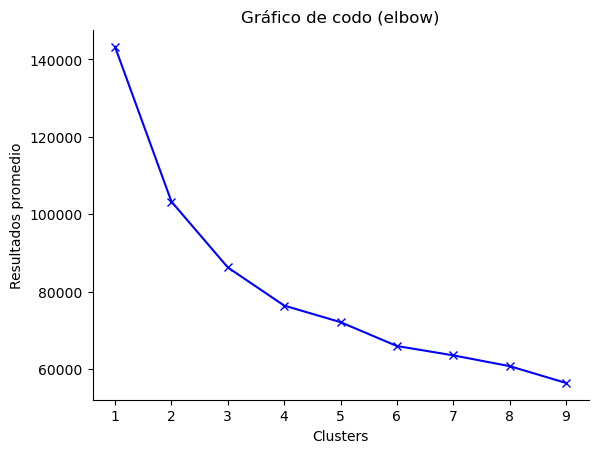

In [ ]:
# Gráfico de codo (modelo transformado con Yeo-Johnson y Zscore)
clusters1= range(1, 10)
distortions1= []
for k in clusters1:
    model1= KMeans(n_clusters= k, random_state= 42)
    model1.fit(df3)
    distortions1.append(model1.inertia_)      # Inertia es la suma de distancias cuadradas de cada punto a su centroide
plt.plot(clusters1, distortions1, 'bx-')
plt.xlabel('Clusters')
plt.ylabel('Resultados promedio')
plt.title('Gráfico de codo (elbow)')
sns.despine()

In [ ]:
# Se genera el clustering Kmeans con 3 clusters e inicializaciones auto (resultado szcore)
kmeans= KMeans(n_clusters= 3, n_init= 'auto', random_state= 42)
kmeans.fit(df2)

KMeans(n_clusters=3, random_state=42)

In [ ]:
# clustering Kmeans con 3 clusters e inicializaciones auto (resultado Yeo-Johnson, Zscore )
kmeans2= KMeans(n_clusters= 3, n_init= 'auto', random_state= 42)
kmeans2.fit(df3)

KMeans(n_clusters=3, random_state=42)

In [51]:
# Df con las coordenadas de los centroides de cada variable
centroids_df= pd.DataFrame(kmeans2.cluster_centers_, columns= list(df3))
centroids_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.548381,0.524361,0.935688,0.850246,-0.016328,0.940271,0.787270,0.820727,-0.028579,-0.015817,1.018588,0.432014,0.617403,0.510303,-0.075822,0.237454
1,-0.872061,-0.500219,0.190937,0.179843,-0.886568,0.183849,-0.125038,0.121704,-0.838991,-0.858918,0.142846,-0.268662,-0.476707,-0.695861,0.411243,-0.027234
2,0.488194,0.094091,-1.042544,-0.954429,1.004868,-1.038688,-0.558030,-0.863320,0.962577,0.973527,-1.062291,-0.082742,-0.014632,0.325104,-0.392209,-0.180018


In [52]:
# Df para los labels de los clusters por registro
labels_df= pd.DataFrame(kmeans2.labels_, columns= list(['labels']))
labels_df

,labels
0,1
1,2
2,0
3,2
4,1
...,...
8945,1
8946,1
8947,1
8948,2


In [53]:
df3.__len__()

8950

In [54]:
# Unión de las variables con los labels o clases
labeled_df= df3.join(labels_df)

In [55]:
labeled_df.head(3)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,labels
0,-1.238103,-1.079348,-0.368050,0.383704,-0.944538,-0.806490,-0.903315,-0.707313,-0.883204,-0.905801,-0.573664,-1.425353,-0.983876,-0.824388,-0.677889,0.422252,1
1,1.051961,-0.424939,-1.505149,-1.085422,1.399909,-1.221758,-0.903315,-0.916995,1.124423,1.044342,-1.387624,0.924217,1.285321,0.917393,1.235021,0.422252,2
2,0.860616,0.628612,0.521657,-1.085422,-0.944538,1.269843,1.732554,-0.916995,-0.883204,-0.905801,0.494757,1.012194,-0.291722,0.475906,-0.677889,0.422252,0


In [56]:
# Conversión de labels a categoría
labeled_df['labels']= labeled_df['labels'].astype('category')

In [ ]:
# Proporción de clases 
labeled_df['labels'].value_counts()

labels
1    3329
2    2978
0    2643
Name: count, dtype: int64

<Axes: xlabel='labels'>

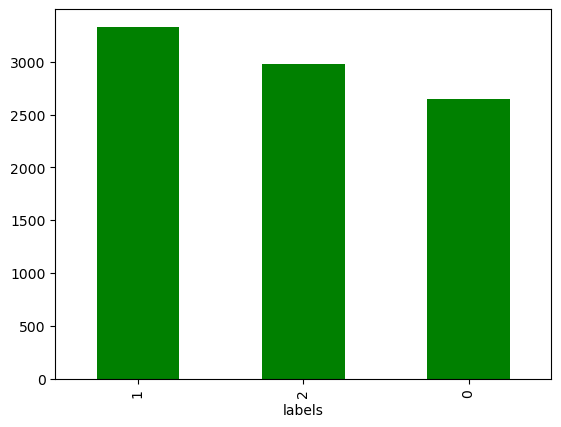

In [139]:
# Gráfico de barras del conteo de clases o labels
labeled_df['labels'].value_counts().plot.bar(color= 'green')

<b>Observaciones:</b>
- Se optó por realizar el modelo de clustering con los resultados generados de la transformación Yeo-Johnson al ser los que contenían menores sesgos en comparación con el primer dataframe. 

#### Clustering Jerárquico (Dendrograma)

In [ ]:
# Importación de librería para realizar el dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage

In [72]:
# Generación de enlaces
Z= linkage(df3, 'average', metric= 'euclidean')
Z.shape

(8949, 4)

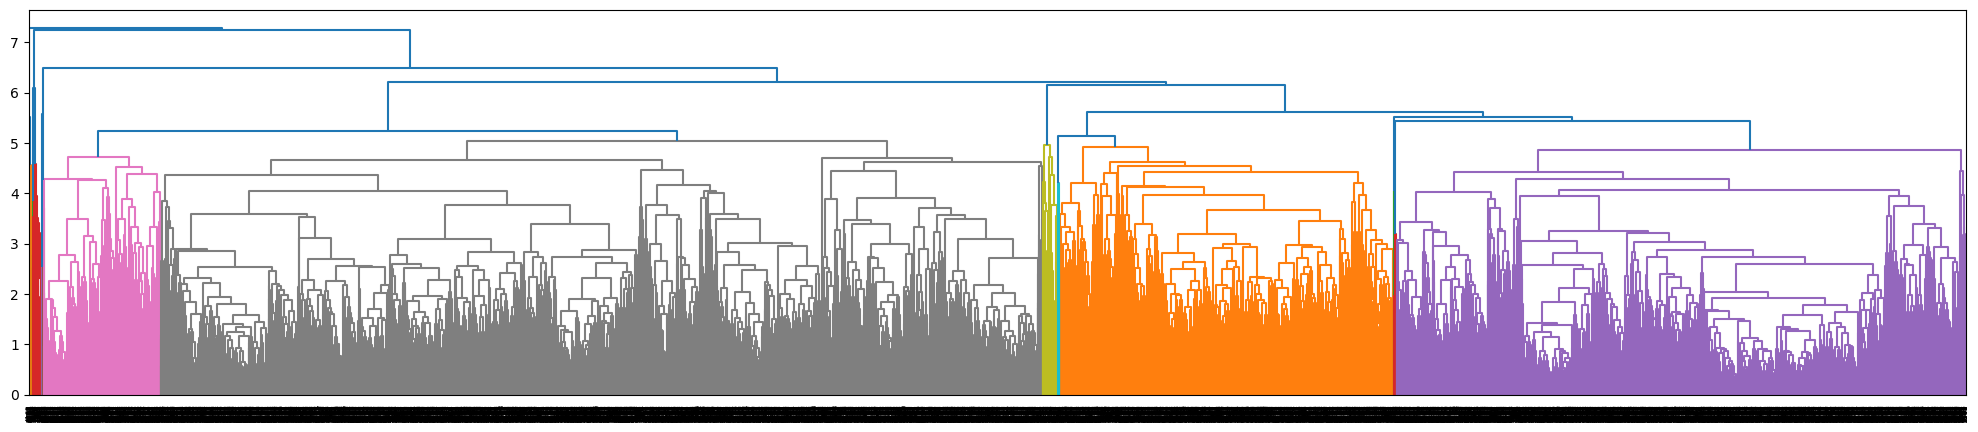

In [73]:
plt.figure(figsize= (25, 5))
dendrogram(Z)
plt.show()

In [74]:
# Cálculo de coeficiente cofenético para validar la calidad del fit
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

c, coph_dist= cophenet(Z, pdist(df3))
print(' Coeficiente cofenético: ', format(c, '.4f'))

 Coeficiente cofenético:  0.6792


<b>Observaciones:</b>
- El dendrograma captura en un 67% la estructura jerárquica de los datos.

#### Silhouette Score

In [26]:
from sklearn.metrics import silhouette_score

In [ ]:
# Fit del primer modelo
preds= kmeans.fit_predict(df2)
preds

array([2, 1, 0, ..., 2, 2, 2], dtype=int32)

In [ ]:
# Fit del segundo modelo
preds2= kmeans2.fit_predict(df3)
preds2

array([1, 2, 0, ..., 1, 2, 1], dtype=int32)

In [75]:
print('Silhouette Score del primer modelo : ', silhouette_score(df2, preds, metric= 'euclidean'))

Silhouette Score del primer modelo :  0.20976149447661463


In [76]:
print('Silhouette Score del segundo modelo: ', silhouette_score(df3, preds2, metric= 'euclidean'))

Silhouette Score del segundo modelo:  0.2336024209938144


In [ ]:
# Valor de Silhouette para cada punto
from sklearn.metrics import silhouette_samples 
sample= silhouette_samples(df3, kmeans2.labels_)
sample

array([2.65693670e-01, 4.24158487e-01, 8.06349247e-02, ...,
       3.02786371e-01, 9.05678777e-02, 1.67012455e-04])

In [ ]:
# Se genera un df con la media de silhouette por cluster
sample_cluster= pd.DataFrame({'Cluster': kmeans2.labels_, 'Silhouette': sample}).groupby('Cluster').mean()

In [ ]:
# Reset al index para 'aplanar' los ejes de columnas
sample_cluster= sample_cluster.reset_index()

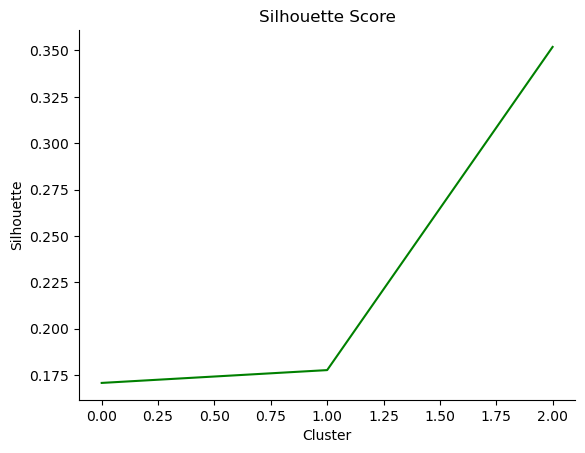

In [136]:
sns.lineplot(sample_cluster, x= 'Cluster', y= 'Silhouette', errorbar= None, color= 'green')
plt.title('Silhouette Score')
sns.despine()
plt.show()

<b>Observaciones:</b>
- El segundo modelo (resultado de transformación de Yeo-Johnson) genera un Silhouette score de 0.23, arriba de 0.20 del primer modelo estandarizado sólo con Zscore.<br><br>

- Se realiza la importación de la librería silhouette_samples para obtener el nivel de silhouette para cada valor del modelo y se engloba en un dataframe agrupado por la media de silhouette de cada cluster.<br><br>
- Un Silhouette Score de 0.23 indica una baja calidad de separación entre clusters.

#### Visualización

In [60]:
# Cantidad de columnas del df omitiendo las clases
len(set(labeled_df.columns) - {'labels'})

16

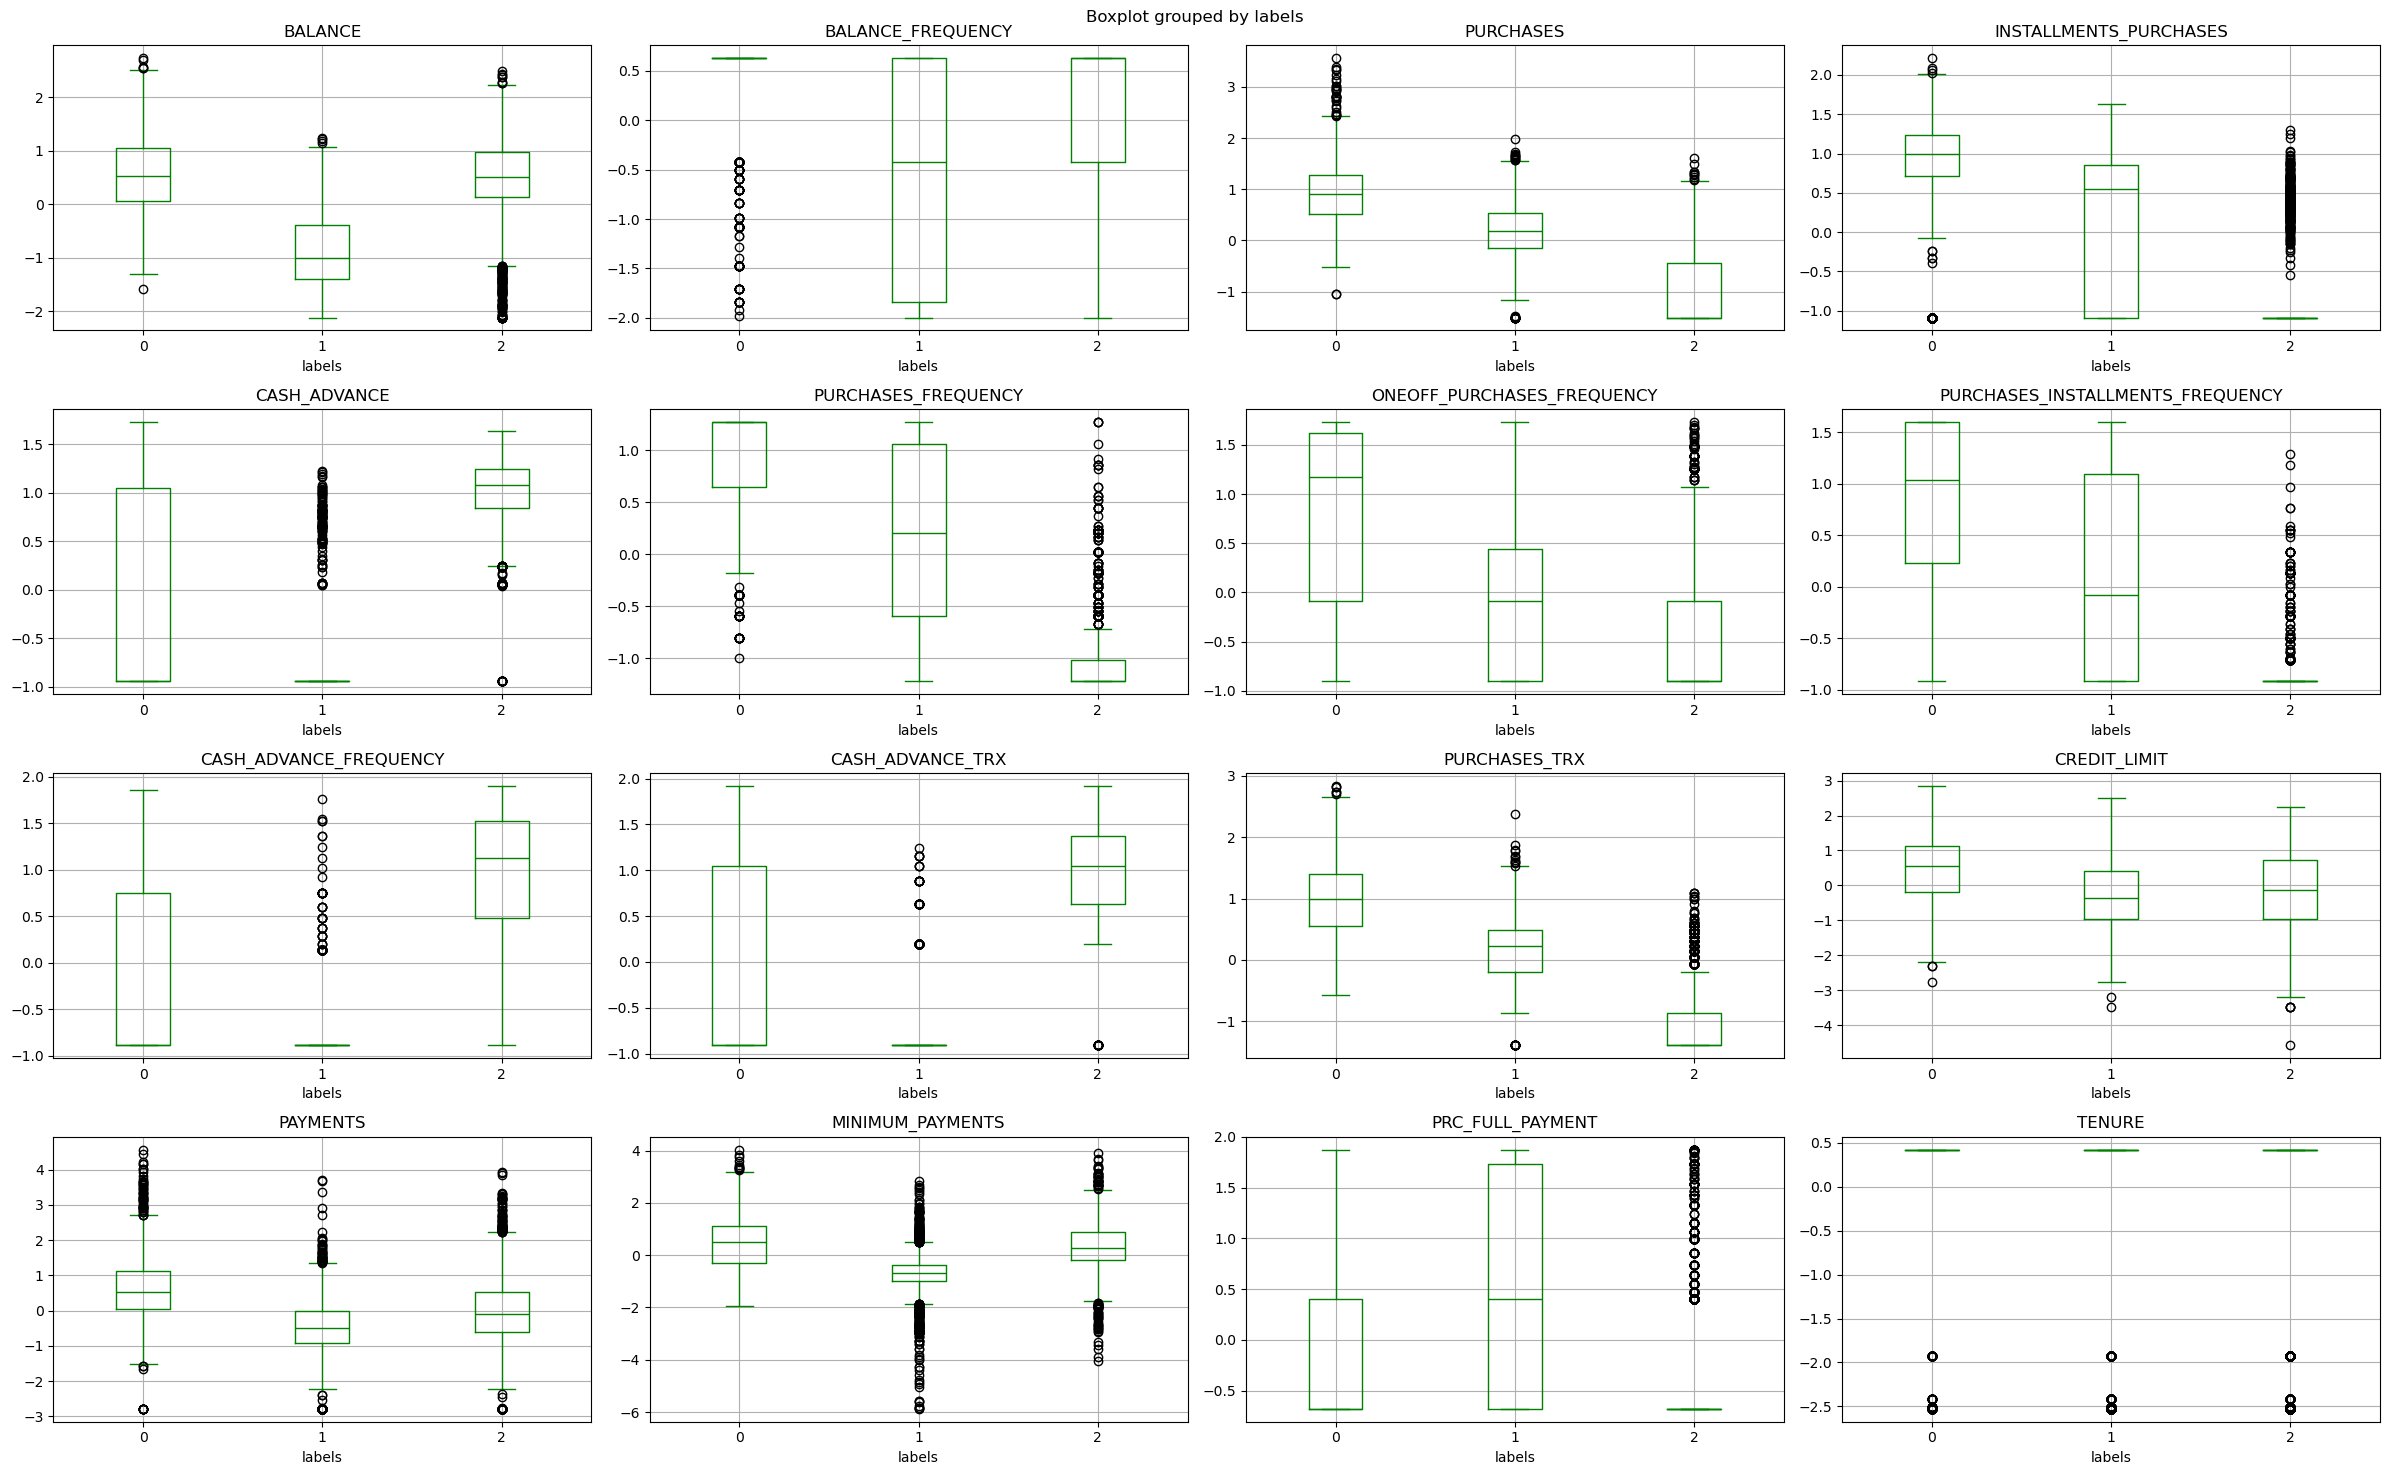

In [61]:
# Gráficos de boxplot de las clases
fig, axes= plt.subplots(4, 4, figsize= (24, 15))
for i, column in enumerate(labeled_df.columns.drop('labels')):              # Se omite la columna de clases en los gráficos
    labeled_df.boxplot(column= column, by= 'labels', ax= axes[i//4, i%4], color= 'green')
plt.tight_layout()
plt.show()

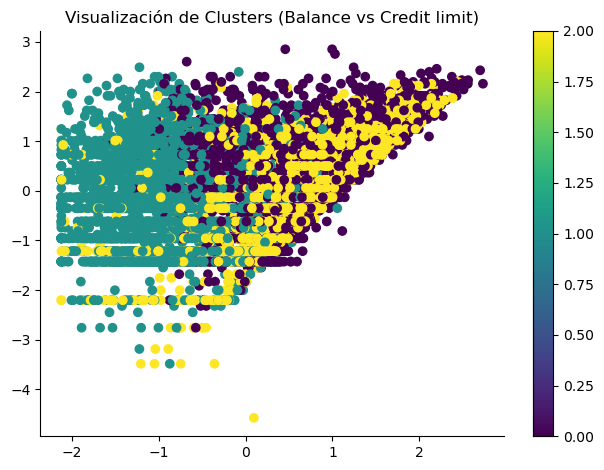

In [ ]:
# Scatter plot de Saldo promedio vs Límite de crédito
fig, ax= plt.subplots()
scatter= ax.scatter(labeled_df['BALANCE'], labeled_df['CREDIT_LIMIT'], c= labeled_df['labels'])
ax.set_title('Visualización de Clusters (Balance vs Credit limit)')
plt.tight_layout()
plt.colorbar(scatter)
sns.despine()
plt.show()


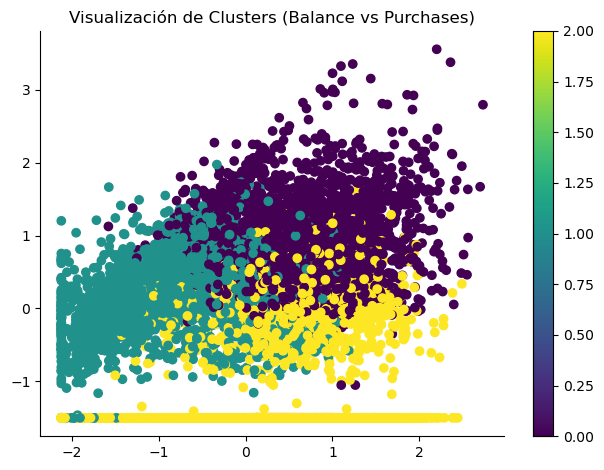

In [ ]:
# Scatter plot de Saldo promedio vs Compras
fig, ax= plt.subplots()
scatter= ax.scatter(labeled_df['BALANCE'], labeled_df['PURCHASES'], c= labeled_df['labels'])
ax.set_title('Visualización de Clusters (Balance vs Purchases)')
plt.tight_layout()
plt.colorbar(scatter)
sns.despine()
plt.show()

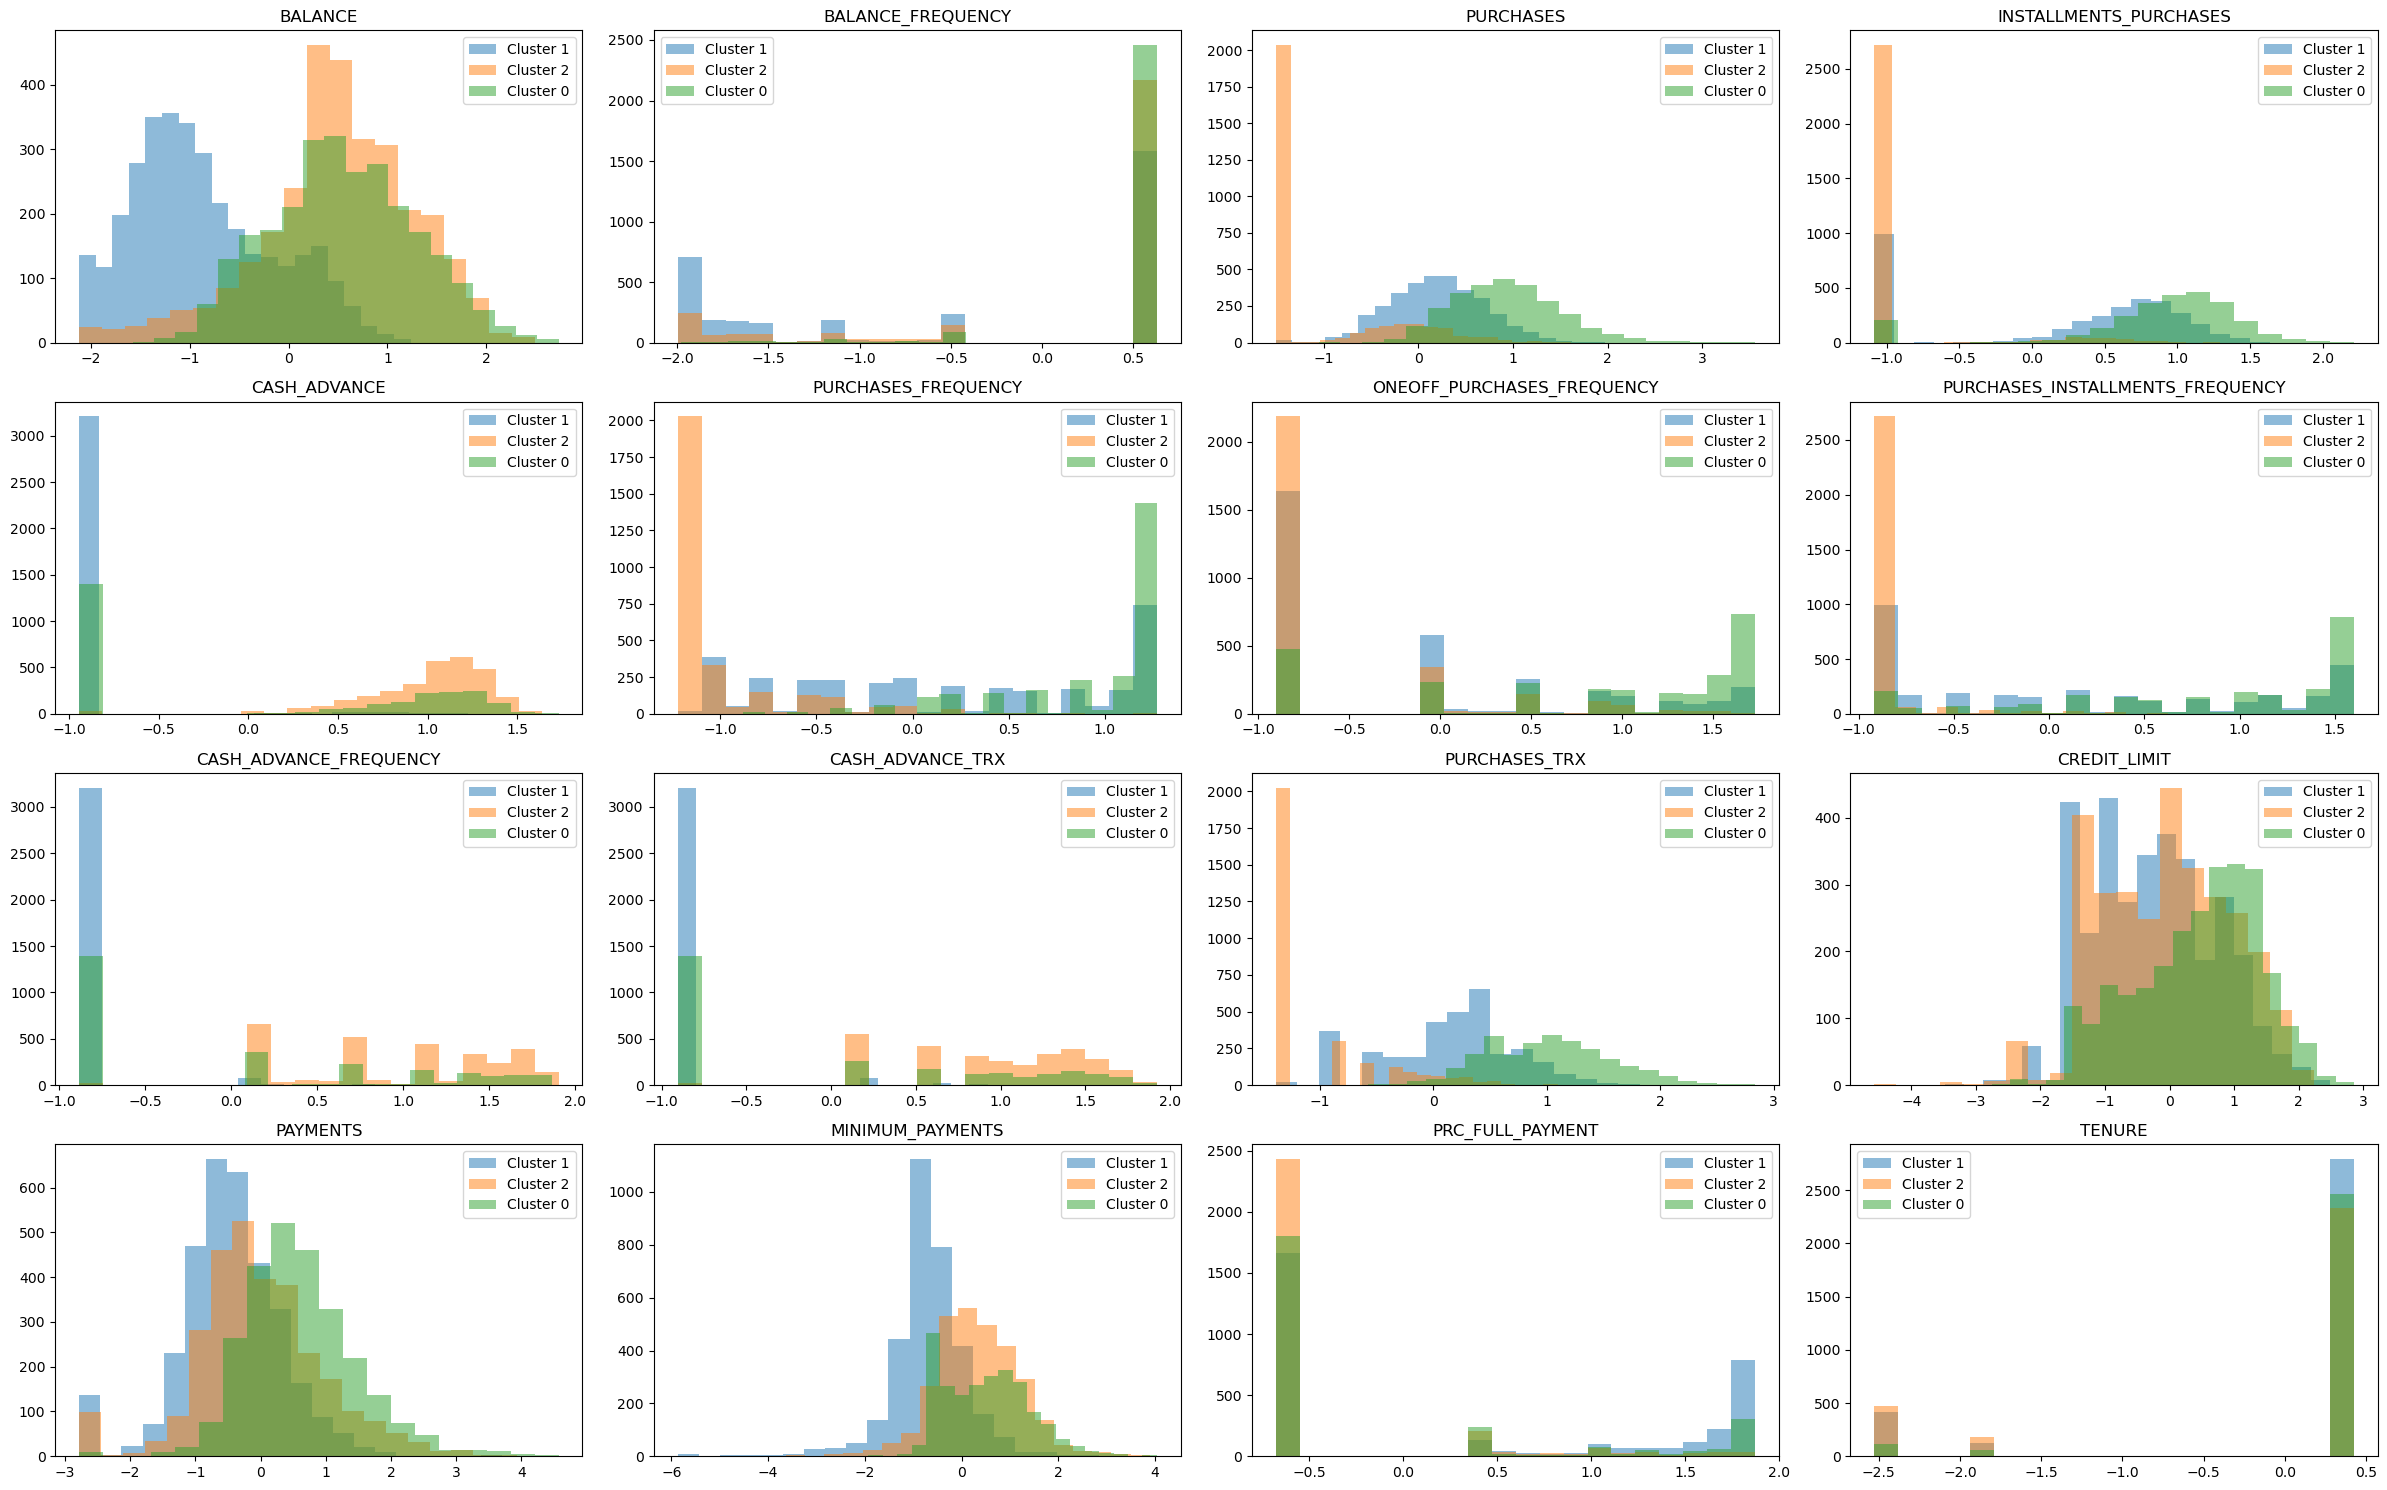

In [ ]:
# Histogramas de las clases
fig, axes= plt.subplots(4, 4, figsize= (24, 15))
for i, column in enumerate(labeled_df.columns.drop('labels')):          # Se omite la columna labels en los gráficos
    ax= axes[i//4, i%4]
    for label in labeled_df['labels'].unique():
        subset= labeled_df[labeled_df['labels'] == label][column]       # Subconjunto que selecciona todas las filas de un determinado cluster
        ax.hist(subset, bins= 20, alpha= 0.5, label=f'Cluster {label}') # Generación de histogramas
    ax.set_title(column)
    ax.legend()
plt.tight_layout()
plt.show()

### <b>Interpretación final de resultados</b>

<span style="color:green">
<b>Cluster 0 (Compradores frecuentes con bajo uso de adelantos en efectivo)</span></b><br><br>

- Clientes con antigüedad y la más alta frecuencia de compras.<br>
- Saldo promedio moderado en la tarjeta que actualizan constantemente.<br>
- No recurren a adelantos de efectivo en su tarjeta frecuentemente.<br>
- Con el límite de crédito más alto.

<b><span style="color:#4ea8de">Cluster 1 (Clientes más antiguos con bajo uso de adelantos en efectivo)</span></b><br><br>

- Clientes con más antigüedad y alta frecuencia de compras. <br>
- El menor saldo promedio en la tarjeta que NO actualizan constantemente.<br>
- No recurren a adelantos en efectivo en su tarjeta frecuentemente.<br>
- Límite de crédito moderado, similar al cluster 2.

<b><span style="color:orange">Cluster 2 (Clientes nuevos con alto uso de adelantos en efectivo)</span></b><br><br>

- Clientes de menor antigüedad y baja frecuencia de compras. <br>
- El mayor saldo promedio moderado en la tarjeta que NO actualizan constantemente.<br>
- Realizan adelantos en efectivo en su tarjeta frecuentemente.<br>
- Con el límite de crédito similar al cluster 1.
